In [61]:
import pandas as pd

nasa_1 = pd.read_csv('/content/drive/MyDrive/Dane/NASA-TLX_1.csv')
nasa_2 = pd.read_csv('/content/drive/MyDrive/Dane/NASA-TLX_2.csv')


First measurement



In [44]:
# Define the columns to use for TLX calculation
tlx_dimensions = ['MD', 'PD', 'TD', 'P', 'E', 'F']

# Apply the raw_tlx_score function to each row of the specified columns
nasa_1['Raw TLX Score_1'] = nasa_1[tlx_dimensions].apply(lambda row: raw_tlx_score(row.to_dict()), axis=1)

# Display the first few rows of nasa_1 with the new score column
display(nasa_1.head())

,Sygnatura czasowa,"Identyfikator w badaniu (taki sam, jak w systemie Argilla)",MD,PD,TD,P,E,F,Raw TLX Score_1
0,2025-11-09 20:21:34,annotator_II_faza_8,10,1,1,20,1,1,34
1,2025-11-12 12:45:08,annotator_II_faza_14,10,10,8,18,10,10,66
2,2025-11-12 19:10:32,annotator_II_faza_18,15,2,2,3,10,1,33
3,2025-11-13 09:26:19,annotator_II_faza_6,20,15,10,15,20,1,81
4,2025-11-14 18:09:42,annotator_II_faza_8,10,1,1,10,10,10,42


In [46]:
average_raw_tlx_score = nasa_1['Raw TLX Score_1'].mean()
std_raw_tlx_score = nasa_1['Raw TLX Score_1'].std()
min_raw_tlx_score = nasa_1['Raw TLX Score_1'].min()
max_raw_tlx_score = nasa_1['Raw TLX Score_1'].max()
print(f"Average Raw TLX Score: {average_raw_tlx_score}")
print(f"Standard Deviation of Raw TLX Score: {std_raw_tlx_score}")
print(f"Minimum Raw TLX Score: {min_raw_tlx_score}")
print(f"Maximum Raw TLX Score: {max_raw_tlx_score}")

Average Raw TLX Score: 50.8
Standard Deviation of Raw TLX Score: 15.945218719101975
Minimum Raw TLX Score: 25
Maximum Raw TLX Score: 81


Second measurement

In [51]:
# Define the columns to use for TLX calculation
tlx_dimensions= ['MD', 'PD', 'TD', 'P', 'E', 'F']

# Apply the raw_tlx_score function to each row of the specified columns
nasa_2['Raw TLX Score_2'] = nasa_2[tlx_dimensions].apply(lambda row: raw_tlx_score(row.to_dict()), axis=1)

# Display the first few rows of nasa_1 with the new score column
display(nasa_2.head())

,Sygnatura czasowa,"Identyfikator w badaniu (taki sam, jak w systemie Argilla)",MD,PD,TD,P,E,F,Raw TLX Score_2
0,2025-12-18 15:45:00,annotator_II_faza_10,11,12,14,16,13,8,74
1,2025-12-18 15:48:32,annotator_II_faza_23,6,5,7,3,8,7,36
2,2025-12-18 16:47:15,annotator_II_faza_11,15,5,1,1,10,7,39
3,2025-12-18 17:37:24,annotator_II_faza_13,8,4,5,2,6,17,42
4,2025-12-18 18:02:08,annotator_II_faza_21,15,2,12,5,5,6,45


In [56]:
combined_nasa['Raw TLX Score'] = combined_nasa['Raw TLX Score_1'].fillna(combined_nasa['Raw TLX Score_2'])

print("Combined 'Raw TLX Score' column created successfully.")
# Display the first few rows to verify the new column
display(combined_nasa.head())

Combined 'Raw TLX Score' column created successfully.


,Sygnatura czasowa,"Identyfikator w badaniu (taki sam, jak w systemie Argilla)",MD,PD,TD,P,E,F,Raw TLX Score_1,MEASUREMENT,Raw TLX Score_2,Raw TLX Score
0,2025-11-09 20:21:34,annotator_II_faza_8,10,1,1,20,1,1,34.0,first,NaN,34.0
1,2025-11-12 12:45:08,annotator_II_faza_14,10,10,8,18,10,10,66.0,first,NaN,66.0
2,2025-11-12 19:10:32,annotator_II_faza_18,15,2,2,3,10,1,33.0,first,NaN,33.0
3,2025-11-13 09:26:19,annotator_II_faza_6,20,15,10,15,20,1,81.0,first,NaN,81.0
4,2025-11-14 18:09:42,annotator_II_faza_8,10,1,1,10,10,10,42.0,first,NaN,42.0


Comparison of total TLX score

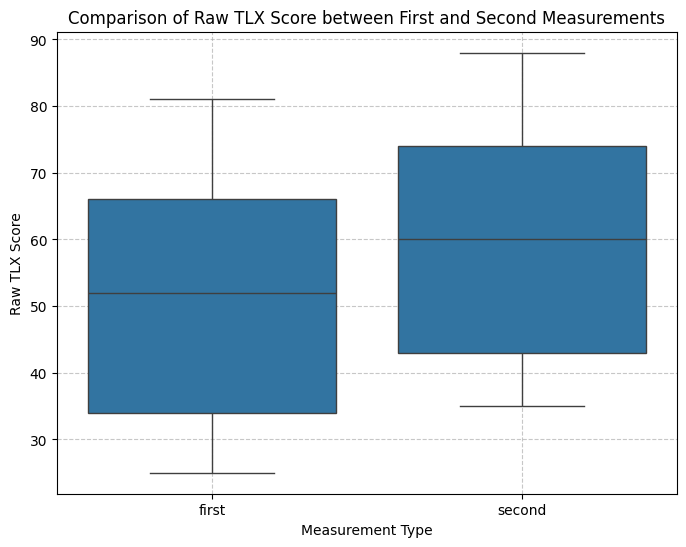

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='MEASUREMENT', y='Raw TLX Score', data=combined_nasa)
plt.title('Comparison of Raw TLX Score between First and Second Measurements')
plt.xlabel('Measurement Type')
plt.ylabel('Raw TLX Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
Comparison of TLX dimensions

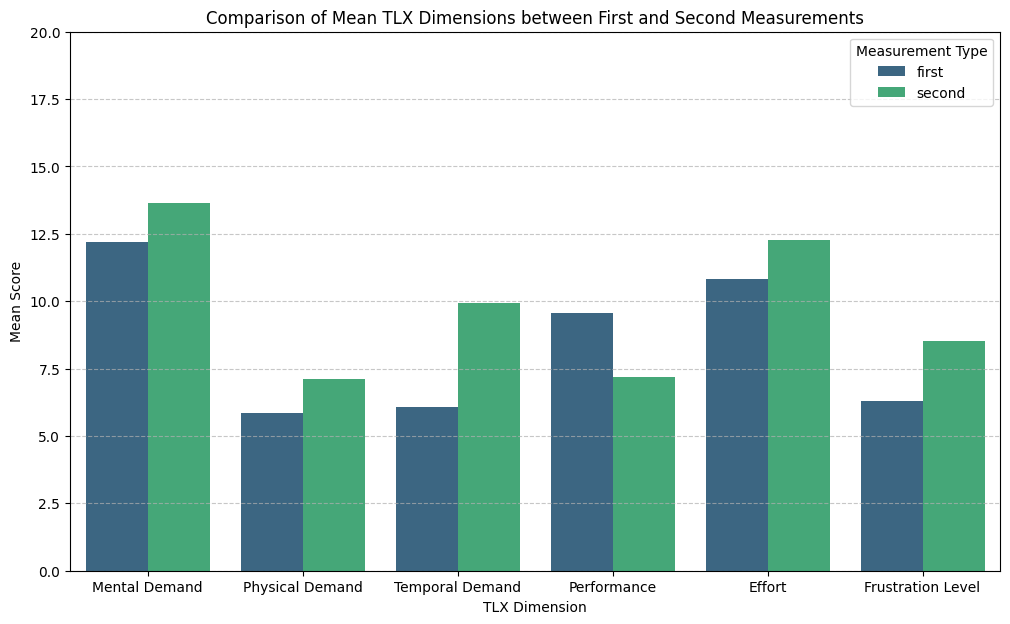

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the list of individual TLX dimensions
tlx_dimensions = ['MD', 'PD', 'TD', 'P', 'E', 'F']

# Create a dictionary to map short names to full names for plotting
dimension_labels = {
    'MD': 'Mental Demand',
    'PD': 'Physical Demand',
    'TD': 'Temporal Demand',
    'P': 'Performance',
    'E': 'Effort',
    'F': 'Frustration Level'
}

# Calculate the mean for each TLX dimension, grouped by MEASUREMENT
mean_tlx_scores = combined_nasa.groupby('MEASUREMENT')[tlx_dimensions].mean().reset_index()

# Reshape the DataFrame for plotting (melt the dimensions into a single column)
mean_tlx_scores_melted = mean_tlx_scores.melt(id_vars='MEASUREMENT', var_name='TLX Dimension', value_name='Mean Score')

# Map the short dimension names to their full labels in the melted DataFrame
mean_tlx_scores_melted['TLX Dimension'] = mean_tlx_scores_melted['TLX Dimension'].map(dimension_labels)

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='TLX Dimension', y='Mean Score', hue='MEASUREMENT', data=mean_tlx_scores_melted, palette='viridis')
plt.title('Comparison of Mean TLX Dimensions between First and Second Measurements')
plt.xlabel('TLX Dimension')
plt.ylabel('Mean Score')
plt.ylim(0, 20) # Set y-axis limit to 20
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Measurement Type')
plt.show()